In [16]:
%pip install yfinance
%pip install bs4
%pip install requests
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\debje\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\debje\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\debje\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\debje\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [17]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [18]:
tesla = yf.Ticker("TSLA")

tesla_data = tesla.history(period="max")

tesla_data.reset_index(inplace=True)

tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [24]:
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html_data = requests.get(url, headers=headers).text

In [25]:
soup = BeautifulSoup(html_data, "html.parser")

In [26]:
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

In [27]:
tables = soup.find_all("table")

for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        tesla_table = table

In [28]:
for row in tesla_table.find_all("tr"):
    cols = row.find_all("td")

    if len(cols) != 0:
        date = cols[0].text
        revenue = cols[1].text

        tesla_revenue = pd.concat([
            tesla_revenue,
            pd.DataFrame({
                "Date": [date],
                "Revenue": [revenue]
            })
        ], ignore_index=True)

In [29]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',', "")
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace('$', "")

In [30]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [31]:
tesla_revenue.tail()

,Date,Revenue
55,2012-06-30,27
56,2012-03-31,30
57,2011-12-31,39
58,2011-09-30,58
59,2011-06-30,58


In [32]:
gme = yf.Ticker("GME")

gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)

gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693349,1.603295,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [41]:
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html_data = requests.get(url, headers=headers).text

In [45]:
soup = BeautifulSoup(html_data, "html.parser")

In [46]:
tables = soup.find_all("table")

len(tables)

4

In [47]:
for table in tables:
    if "GameStop Quarterly Revenue" in table.text:
        gme_table = table
        break

In [48]:
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in gme_table.find_all("tr"):

    cols = row.find_all("td")

    if len(cols) != 0:

        date = cols[0].text
        revenue = cols[1].text

        gme_revenue = pd.concat([
            gme_revenue,
            pd.DataFrame({
                "Date": [date],
                "Revenue": [revenue]
            })
        ], ignore_index=True)

In [49]:
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "")
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "")

gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

In [50]:
gme_revenue.tail()

,Date,Revenue
54,2012-07-31,1550
55,2012-04-30,2002
56,2012-01-31,3579
57,2011-10-31,1947
58,2011-07-31,1744


In [55]:
gme = yf.Ticker("GME")

gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)

gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [56]:
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html_data = requests.get(url, headers=headers).text

In [57]:
soup = BeautifulSoup(html_data, "html.parser")

In [58]:
tables = soup.find_all("table")

for table in tables:
    if "GameStop Quarterly Revenue" in table.text:
        gme_table = table
        break

In [59]:
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in gme_table.find_all("tr"):

    cols = row.find_all("td")

    if len(cols) != 0:

        date = cols[0].text
        revenue = cols[1].text

        gme_revenue = pd.concat([
            gme_revenue,
            pd.DataFrame({
                "Date": [date],
                "Revenue": [revenue]
            })
        ], ignore_index=True)

In [60]:
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "")
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "")

gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

In [61]:
gme_revenue.tail()

,Date,Revenue
54,2012-07-31,1550
55,2012-04-30,2002
56,2012-01-31,3579
57,2011-10-31,1947
58,2011-07-31,1744


In [62]:
def make_graph(stock_data, revenue_data, stock):

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=("Historical Share Price", "Historical Revenue"),
        vertical_spacing=.3
    )

    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']

    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(stock_data_specific.Date),
            y=stock_data_specific.Close.astype("float"),
            name="Share Price"
        ),
        row=1,
        col=1
    )

    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(revenue_data_specific.Date),
            y=revenue_data_specific.Revenue.astype("float"),
            name="Revenue"
        ),
        row=2,
        col=1
    )

    fig.update_layout(
        showlegend=False,
        height=900,
        title=stock
    )

    fig.show()

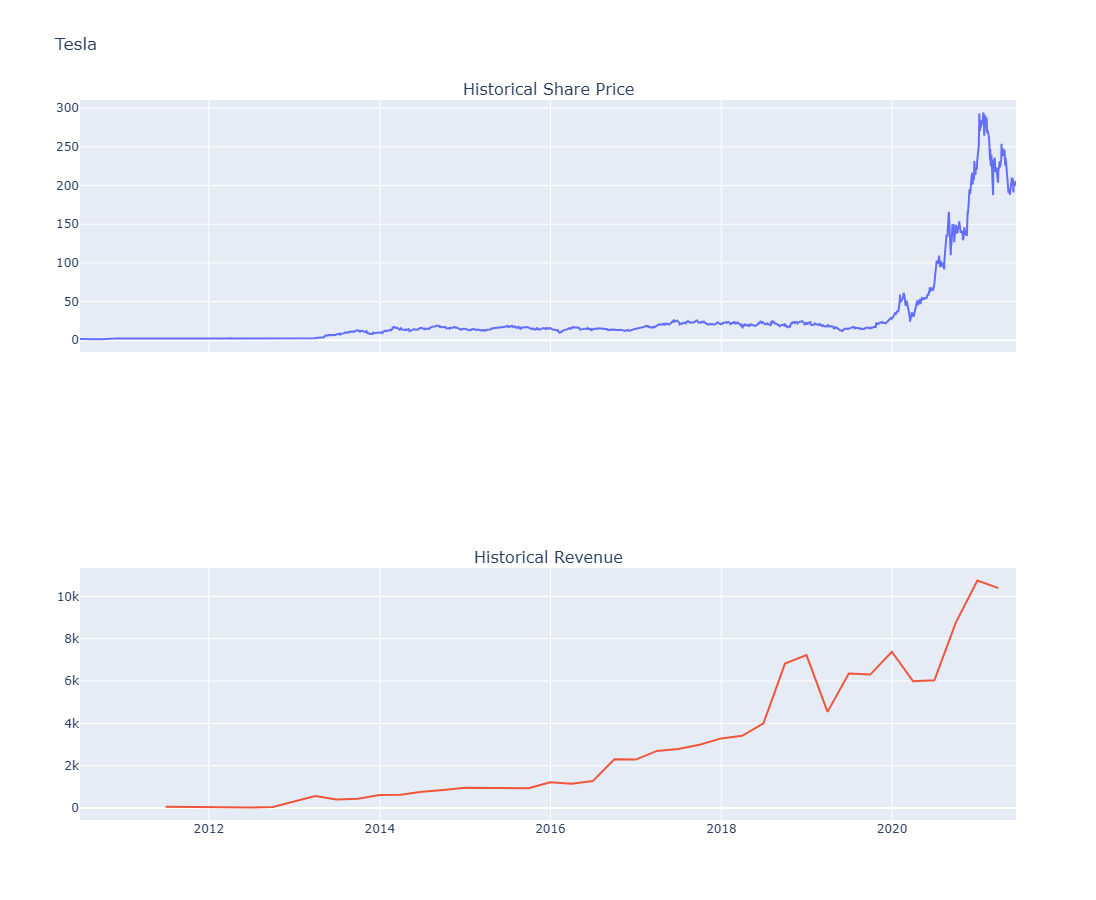

In [63]:
make_graph(tesla_data, tesla_revenue, 'Tesla')